In [5]:
import kagglehub
import os
import random
from pathlib import Path
import torch
import math
import sys
import time

from abc import ABC, abstractmethod

import torch
import torchvision.models.detection.mask_rcnn


import datetime
import errno
import os
import time
from collections import defaultdict, deque

import torch
import torch.distributed as dist


import cv2
import json
import numpy as np
from PIL import Image
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CocoDetection
import torchvision
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

from torchvision.models.detection import RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.models.detection.retinanet import RetinaNetClassificationHead


import torchvision.transforms.v2 as T
import torch.nn as nn
from pycocotools.coco import COCO

from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)

import albumentations as A


In [ ]:
# Download latest version
dataset_path = Path(kagglehub.dataset_download("flyingfriedrice/8-gaze-directions-detection"))
dataset_str = str(dataset_path)

print("Path to dataset files:", dataset_path)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 1

Path to dataset files: /Users/annabied/.cache/kagglehub/datasets/flyingfriedrice/8-gaze-directions-detection/versions/1


## Canonical Dataset
This canonical dataset

Clean the background class from canonical dataset because our models will need different background indeces


In [7]:
class GazeDetection(Dataset):
    def __init__(self, root_string, ann_file, transform):
        self.root = root_string
        self.annFile = ann_file
        self.transform = transform
        
        self.coco = COCO(self.annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))

        real_cat_ids = sorted(self.coco.getCatIds())
        real_cat_ids = [cid for cid in real_cat_ids if cid != 0]
        self.catid2label = {cid: i for i, cid in enumerate(real_cat_ids)} 

    def _load_image(self, id):
        path = self.coco.loadImgs(id)[0]["file_name"]
        return Image.open(os.path.join(self.root, path)).convert("RGB")
    
    def _load_target(self, image_id):
        ann_ids = self.coco.getAnnIds(image_id)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []

        for a in anns:
            category_id = a["category_id"]

            # skip Roboflow background category
            if category_id == 0:
                continue

            # remap remaining categories
            label = self.catid2label[category_id]

            x, y, w, h = a["bbox"]

            if w <= 0 or h <= 0:
                continue

            x1, y1, x2, y2 = x, y, x + w, y + h

            boxes.append([x1, y1, x2, y2])
            labels.append(label)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor(image_id, dtype=torch.int64)
        }

        return target


    def __getitem__(self, idx):
        image_id = self.ids[idx]
        image = self._load_image(image_id)
        annotations = self._load_target(image_id)

        if self.transform is not None:
            image, annotations = self.transform(image, annotations)
        
        return image, annotations
    
   
    def __len__(self):
        return len(self.ids)
    
    
    @staticmethod
    def collate_fn(batch):
        """
        Since each image can have a different number of bounding boxes,
        we stack the images but keep targets as a list.
        """
        images = [item[0] for item in batch]
        targets = [item[1] for item in batch]
        return images, targets

In [8]:
train_dataset = GazeDetection(dataset_str + "/GazePerson2/train/", dataset_str + "/GazePerson2/train/_annotations.coco.json", None)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=GazeDetection.collate_fn
)



loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [9]:
train_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    None
)

# 1. What the mapping itself claims
print("catid2label mapping:", train_dataset.catid2label)
print("Number of mapped classes:", len(train_dataset.catid2label))

# 2. What labels ACTUALLY show up when you iterate the dataset
all_labels = set()
for i in range(len(train_dataset)):
    _, target = train_dataset[i]
    all_labels.update(target["labels"].tolist())

print("Unique labels actually produced:", sorted(all_labels))
print("Count:", len(all_labels))
assert sorted(all_labels) == list(range(8)), f"Expected labels 0-7, got {sorted(all_labels)}"

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
catid2label mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}
Number of mapped classes: 8
Unique labels actually produced: [0, 1, 2, 3, 4, 5, 6, 7]
Count: 8


In [10]:
images, targets = next(iter(train_loader))

for t in targets:
    print(torch.unique(t["labels"]))

tensor([2, 3, 4, 5, 7])
tensor([2, 4, 5])
tensor([5])
tensor([0, 4])


In [11]:
# @interface
class BaseModelAdapter(nn.Module, ABC):
    def __init__(self, output_classes:int, device=DEVICE):
        super().__init__()
        self.output_classes = output_classes
        self.device = device

    # Must return a unified loss float tensor.
    @abstractmethod
    def forward_train(self, images, annotations):
        pass
    
    # Convert canonical dataset format into model specific format
    @abstractmethod
    def prepare_item(self, images, annotations):
        pass


    # utility method for deriving annotations for prepare_item
    def _get_annotations(self, images, annotations):
        targets = []
        for ann, img in zip(annotations, images):
            boxes = ann["boxes"].detach().clone().to(self.device, dtype=torch.float32)
            if boxes.numel() == 0:
                boxes = boxes.reshape(0, 4)
            assert boxes.ndim == 2 and boxes.shape[1] == 4, \
                f"Malformed boxes tensor: {boxes.shape}"          

            labels = (ann["labels"].detach().clone()).to(self.device, dtype=torch.int64)
            assert labels.min() >= 0 and labels.max() <= self.output_classes - 1, \
                f"Label out of range: min={labels.min().item()}, " \
                f"max={labels.max().item()}, expected [0, {self.output_classes - 1}]"

            targets.append({
                "image_id": int(ann["image_id"]),   # avoid type error if accidentially became 0-dim tensor (but like it shouldn't)
                "boxes": boxes,
                "labels": labels
            })

        return targets
    
    # utility method
    @staticmethod
    def convert_voc2coco(bbox):
        x1, y1, x2, y2 = bbox
        w = x2 - x1
        h = y2 - y1
        return [x1, y1, w, h]

In [12]:
# utility method
def plot_predictions(img, results, dataset, threshold=0.5, ax=None):
    # 1. Build the label-to-name mapping dynamically using your dataset's structures
    label_to_name = {}
    for cat_id, cat_info in dataset.coco.cats.items():
        if cat_id in dataset.catid2label:
            mapped_label = dataset.catid2label[cat_id]
            label_to_name[mapped_label] = cat_info["name"]

    # 2. Setup the plot if an axis isn't provided
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(12, 8))
    
    ax.imshow(img)
    
    # 3. Extract predictions
    pred_boxes = results["boxes"].cpu()
    pred_scores = results["scores"].cpu()
    pred_labels = results["labels"].cpu()
    
    # 4. Draw predicted bounding boxes and labels
    for box, score, label_tensor in zip(pred_boxes, pred_scores, pred_labels):
        score_val = score.item()
        if score_val < threshold:
            continue
            
        label_id = label_tensor.item()
        class_name = label_to_name.get(label_id, f"Class {label_id}")
        
        # Convert [xmin, ymin, xmax, ymax] to [xmin, ymin, width, height] for matplotlib
        xmin, ymin, xmax, ymax = box.tolist()
        width, height = xmax - xmin, ymax - ymin
        
        # Draw the bounding box
        rect = patches.Rectangle(
            (xmin, ymin), width, height, 
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        
        # Draw the text background and label
        ax.text(
            xmin, ymin - 5, 
            f"{class_name}: {score_val:.2f}", 
            color="white", 
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.6, edgecolor="none", pad=2)
        )
        
    ax.axis("off")
    
    if ax is None:
        plt.show()



# Augmentation and Preprocessing

In [13]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(scale=(0.02, 0.05), p=0.15),
        A.HorizontalFlip(p=0.0),    # You must never flip horizontally without changing the labels, too
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
            A.CLAHE(clip_limit=3.0, p=1.0),
        ], p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.1),
        A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.15),
        A.ToGray(p=0.10),
        A.GaussNoise(var_limit=(5.0, 20.0), p=0.15),
        A.ImageCompression(quality_range=(75, 100), p=0.15),

        A.SafeRotate(limit=10, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

# wrap into Albumentations as dataset expects
class AlbumentationsTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, image, target):
        image = np.array(image)

        output = self.transform(
            image=image,
            bboxes=target["boxes"].numpy(),
            category=target["labels"].numpy(),
        )

        image = Image.fromarray(output["image"])

        target = {
            "boxes": torch.as_tensor(output["bboxes"], dtype=torch.float32),
            "labels": torch.as_tensor(output["category"], dtype=torch.int64),
        }

        return image, target

/var/folders/kv/wlmw450x1_16f8t5cd78jzh00000gn/T/ipykernel_1550/838814361.py:12: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.15),
/var/folders/kv/wlmw450x1_16f8t5cd78jzh00000gn/T/ipykernel_1550/838814361.py:15: UserWarning: Argument(s) 'value' are not valid for transform SafeRotate
  A.SafeRotate(limit=10, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.8),


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


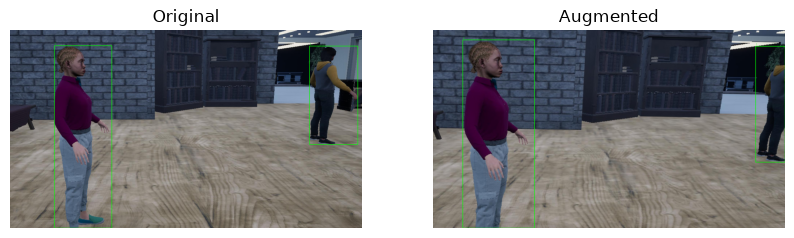

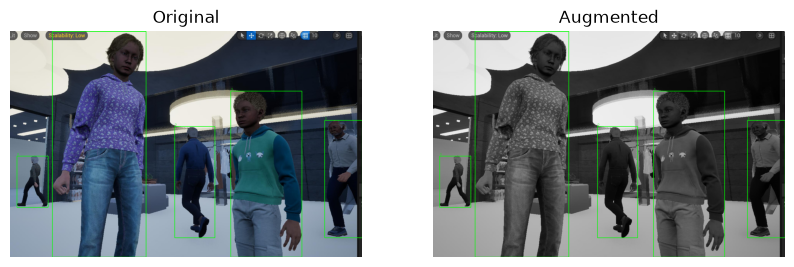

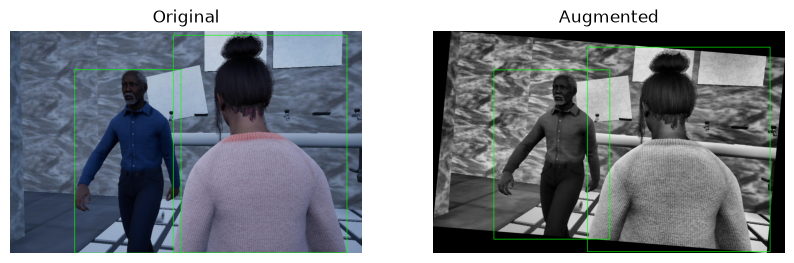

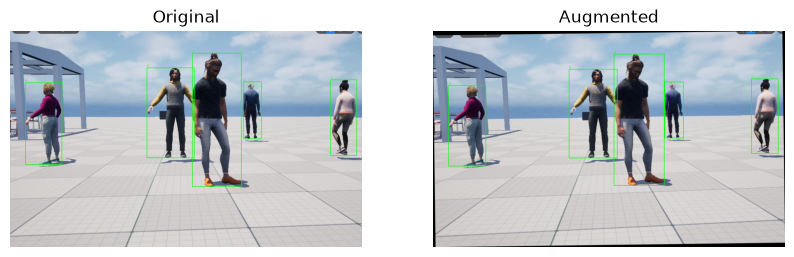

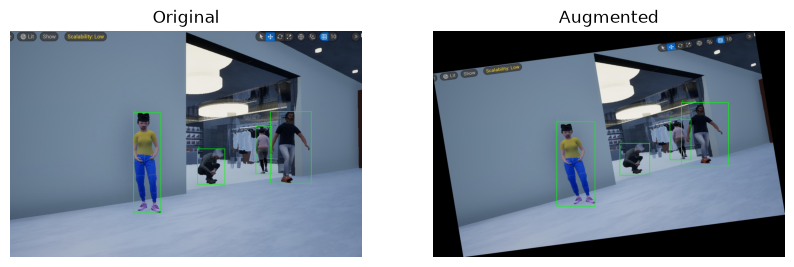

In [14]:
IMAGE_COUNT = 5

orig_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    transform=None,
)

aug_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    transform=AlbumentationsTransform(train_augmentation_and_transform),
)

def draw_boxes(image, boxes, labels):
    img = np.array(image).copy()
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, str(int(label)), (x1, max(y1 - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return img

for i in range(IMAGE_COUNT):
    orig_image, orig_target = orig_dataset[i]
    aug_image, aug_target = aug_dataset[i]  # same index -> same source sample

    original_vis = draw_boxes(orig_image, orig_target["boxes"], orig_target["labels"])
    augmented_vis = draw_boxes(aug_image, aug_target["boxes"], aug_target["labels"])

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_vis); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(augmented_vis); ax[1].set_title("Augmented"); ax[1].axis("off")
    plt.show()

# Train Faster-RCNN

In [ ]:
train_dataset = GazeDetection(
    dataset_str + "/GazePerson2/train/",
    dataset_str + "/GazePerson2/train/_annotations.coco.json",
    AlbumentationsTransform(train_augmentation_and_transform),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=GazeDetection.collate_fn
)



val_dataset = GazeDetection(
    dataset_str + "/GazePerson2/valid/",
    dataset_str + "/GazePerson2/valid/_annotations.coco.json",
    AlbumentationsTransform(valid_transform)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=GazeDetection.collate_fn
)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [10]:
# handle the background class for torchvision by +1 shift of classes, so background class is at index 0
class FasterRCNNAdapter(BaseModelAdapter):
    def __init__(self, model, dataset_classes, device=DEVICE):
        output_classes = dataset_classes + 1  # +1 for background

        super().__init__(output_classes = output_classes, device=device)
        self.model = model

        print(f"Model: {self.model}\nHead classes (incl. background): {self.output_classes}\nDevice: {self.device}")

    # add background class at index 0; FasterRCNN expects float images in [0,1]
    def prepare_item(self, images, annotations):
        # prepare annotations, give +1 to accater for bkrgd class
        targets = self._get_annotations(images, annotations) # pull down from parent
        for t in targets:
            t["labels"] = t["labels"] + 1
            if t["labels"].numel() > 0:
                assert t["labels"].min() >= 1 and t["labels"].max() <= self.output_classes - 1, \
                    f"Label out of range after shift: min={t['labels'].min().item()}, " \
                    f"max={t['labels'].max().item()}, expected [1, {self.output_classes - 1}]"
        
        # prepare the images: Faster RCNN expects float tensors in range [0, 1]
        tensor_images = []
        for img in images:
            np_img = np.array(img, dtype=np.float32) / 255.0
            torch_img = torch.from_numpy(np_img).permute(2, 0, 1).to(self.device)
            tensor_images.append(torch_img)
        
        return tensor_images, targets


    def forward_train(self, images, annotations):
        tensor_images, targets = self.prepare_item(images, annotations)
        loss_dict = self.model(tensor_images, targets)
        return sum(loss for loss in loss_dict.values())
    


In [11]:
dataset_classes = len(train_dataset.catid2label)        # +1 for the background class at 0
output_classes = dataset_classes + 1        # +1 for the background class at 0
print(output_classes)

rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)

 # get number of input features for the classifier
in_features = rcnn_model.roi_heads.box_predictor.cls_score.in_features

# replace the pre-trained head with a new one
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, output_classes) 
rcnn_model.to(DEVICE)

rcnn_adapter = FasterRCNNAdapter(model=rcnn_model, dataset_classes=dataset_classes)

9
Model: FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bi

<ul>
<li>(cls_score): Linear(in_features=1024, out_features=9, bias=True), 8 classes plus background class
<li>(bbox_pred): Linear(in_features=1024, out_features=36, bias=True), the previous 9 classes each giving 4 dimensions (x, y, w, h)
</ul>
I.O.


In [12]:
# construct an optimizer
params = [p for p in rcnn_model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, 
                            lr=0.005,
                            momentum=0.9, 
                            weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=3,
                                               gamma=0.1)

In [13]:
# strongly simplified
def train_one_epoch(adapter_model, dataloader, optimizer, device=DEVICE):
    # Place the internal model explicitly into training mode
    adapter_model.train()
    
    running_loss = 0.0
    
    # Progress bar for clean log telemetry
    pbar = tqdm(dataloader, desc="Training")
    
    for batch_idx, (images, annotations) in enumerate(pbar):
        # 1. Zero out previous gradients
        optimizer.zero_grad()
        
        # 2. Forward pass through our clean interface boundary
        # The adapter handles all device movement and data reshaping internally!
        loss = adapter_model.forward_train(images, annotations)
        
        # 3. Check for numerical instability (gracefully prevent NaN crashes)
        if not torch.isfinite(loss):
            print(f"\n[Warning] Loss is {loss.item()}, skipping batch {batch_idx}")
            continue
            
        # 4. Backward pass & step optimization weight modifications
        loss.backward()
        optimizer.step()
        
        # 5. Track operational telemetry metrics
        running_loss += loss.item()
        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})
        
    epoch_loss = running_loss / len(dataloader)
    return epoch_loss


def validate_one_epoch(adapter_model, dataloader):
    adapter_model.train() # Keep train mode active for FasterRCNN loss dicts
    running_val_loss = 0.0
    
    pbar = tqdm(dataloader, desc="Validation", leave=False)
    
    with torch.no_grad():
        for images, annotations in pbar:
            # Let the adapter handle the device shifting and the +1 label logic!
            loss = adapter_model.forward_train(images, annotations)
            
            if torch.isfinite(loss):
                running_val_loss += loss.item()
                
    epoch_val_loss = running_val_loss / len(dataloader)
    return epoch_val_loss

In [14]:

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    
    # 1. Train
    train_loss = train_one_epoch(rcnn_adapter, train_loader, optimizer)
    
    # 2. Validate
    val_loss = validate_one_epoch(rcnn_adapter, val_loader)
    
    # 3. Telemetry Log
    print(f"Epoch {epoch+1} Complete | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")



--- Epoch 1/15 ---


Training: 100%|██████████| 101/101 [00:29<00:00,  3.42it/s, batch_loss=0.4470]


Epoch 1 Complete | Train Loss: 0.6100 | Val Loss: 0.4357

--- Epoch 2/15 ---


Training: 100%|██████████| 101/101 [00:29<00:00,  3.44it/s, batch_loss=0.1879]


Epoch 2 Complete | Train Loss: 0.3390 | Val Loss: 0.3459

--- Epoch 3/15 ---


...

Epoch 13 Complete | Train Loss: 0.0491 | Val Loss: 0.1912

--- Epoch 14/15 ---


Training: 100%|██████████| 101/101 [00:29<00:00,  3.40it/s, batch_loss=0.0638]


Epoch 14 Complete | Train Loss: 0.0431 | Val Loss: 0.2048

--- Epoch 15/15 ---


Training: 100%|██████████| 101/101 [00:29<00:00,  3.41it/s, batch_loss=0.0381]
                                                           

Epoch 15 Complete | Train Loss: 0.0424 | Val Loss: 0.2004


In [15]:
Path("models").mkdir(parents=True, exist_ok=True)
torch.save(rcnn_adapter.model.state_dict(), "models/rcnn_trained_weights.pth")

Sample how to reload

Model: FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias

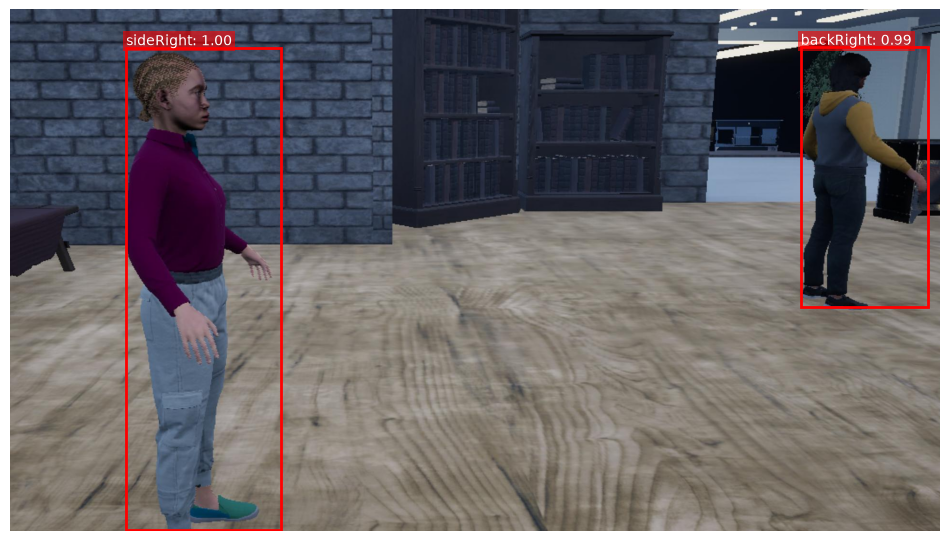

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-create the blank model & adapter setup
rcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(weights=None) # No default weights
rcnn_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, output_classes)

rcnn_adapter_reloaded = FasterRCNNAdapter(model=rcnn_model, dataset_classes=dataset_classes, device=device)

# Load your trained weights straight into the adapter's model
rcnn_adapter_reloaded.model.load_state_dict(torch.load("models/rcnn_trained_weights.pth", map_location=device))
rcnn_adapter_reloaded.model.to(device)
print("Model is loaded and ready on:", device)



img, annotation = train_dataset[0]

np_img = np.array(img, dtype=np.float32) / 255.0
pixel_values = torch.from_numpy(np_img).permute(2, 0, 1).unsqueeze(0)
pixel_values = pixel_values.to(rcnn_adapter_reloaded.device)

rcnn_adapter_reloaded.model.eval()
with torch.no_grad():
    outputs = rcnn_adapter_reloaded.model([pixel_values[0]])

raw_results = outputs[0]

# SHIFT LABELS BACK DOWN BY -1
# This maps the model's indices (1 to 8) back to your dataset's indices (0 to 7)
shifted_labels = raw_results["labels"] - 1

results = {
    "boxes": raw_results["boxes"],
    "scores": raw_results["scores"],
    "labels": shifted_labels  # Use the shifted labels here!
}

# Now index 7 (original 8th class) will display its true category name!
plot_predictions(img, results, train_dataset, threshold=0.5)


## Train RetinaNet
RetinaNet can be imported from torchvision, too. Hence, we are going to use yet another Adapter model from the canonical dataset.

In [17]:
dataset_classes = len(train_dataset.catid2label)      #  RetineNet does not require a background class, use canonical
retinanet_model = torchvision.models.detection.retinanet_resnet50_fpn_v2(weights=RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT)

# get number of anchors per location
num_anchors = retinanet_model.head.classification_head.num_anchors

# get input feature channels
in_channels = retinanet_model.head.classification_head.conv[0][0].in_channels

# replace classification head
retinanet_model.head.classification_head = RetinaNetClassificationHead(
    in_channels,
    num_anchors,
    dataset_classes
)

print(f'Num classes: {dataset_classes}')
print(f"In channels: {in_channels}")
print(f"Number of Retinanet classification classes: {retinanet_model.head.classification_head.num_classes}")
print(f"Number of Retinanet anchors: {retinanet_model.head.classification_head.num_anchors}")

print(train_dataset.catid2label)
retinanet_model.to(DEVICE)


Num classes: 8
In channels: 256
Number of Retinanet classification classes: 8
Number of Retinanet anchors: 9
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}


RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True,

In the output, we see a Sigmoid_focal_loss applied for Retinanet_resnet50_fpn_v2 and no background class mapping.

In [18]:
class RetinaNetAdapter(BaseModelAdapter):
    def __init__(self, model, dataset_classes, device=DEVICE):
        super().__init__(output_classes=dataset_classes, device=device)
        self.model = model

        print(f'Model: {self.model} \n Output classes: {self.output_classes} \n Device: {self.device}')

    def prepare_item(self, images, annotations):
        # prepare annotations: canonical, unshifted — pass straight through
        targets = self._get_annotations(images, annotations)
        
        # prepare images: RetinaNet expects float tensors in range [0, 1]
        tensor_images = []
        for img in images:
            np_img = np.array(img, dtype=np.float32) / 255.0
            tensor_images.append(torch.from_numpy(np_img).permute(2, 0, 1).to(self.device))
        return tensor_images, targets

    def forward_train(self, images, annotations):
        tensor_images, targets = self.prepare_item(images, annotations)

        loss_dict = self.model(tensor_images, targets)
        return sum(loss for loss in loss_dict.values())
    
  

In [19]:
# reuse the resnet params
dataset_classes = len(train_dataset.catid2label)      #  RetineNet does not require a background class, use canonical

params = [p for p in retinanet_model.parameters() if p.requires_grad] # select parameters that require gradient calculation
optimizer = torch.optim.SGD(params, lr=0.005,
                                momentum=0.9, weight_decay=0.0005)

len_dataloader = len(train_loader)

retinanet_adapter = RetinaNetAdapter(retinanet_model, dataset_classes)


for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        
    # 1. Train
    train_loss = train_one_epoch(retinanet_adapter, train_loader, optimizer)
    
    # 2. Validate
    val_loss = validate_one_epoch(retinanet_adapter, val_loader)
    
    # 3. Telemetry Log
    print(f"Epoch {epoch+1} Complete | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Model: RetinaNet(
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

Training: 100%|██████████| 101/101 [00:22<00:00,  4.41it/s, batch_loss=1.2148]


Epoch 1 Complete | Train Loss: 1.0908 | Val Loss: 1.2273

--- Epoch 2/15 ---


Training: 100%|██████████| 101/101 [00:22<00:00,  4.41it/s, batch_loss=1.1679]


Epoch 2 Complete | Train Loss: 1.2163 | Val Loss: 1.1813

--- Epoch 3/15 ---


...

Epoch 13 Complete | Train Loss: 0.3717 | Val Loss: 0.4208

--- Epoch 14/15 ---


Training: 100%|██████████| 101/101 [00:22<00:00,  4.42it/s, batch_loss=0.2956]


Epoch 14 Complete | Train Loss: 0.3431 | Val Loss: 0.4131

--- Epoch 15/15 ---


Training: 100%|██████████| 101/101 [00:22<00:00,  4.39it/s, batch_loss=0.3515]
                                                           

Epoch 15 Complete | Train Loss: 0.3265 | Val Loss: 0.4002


In [20]:
torch.save(retinanet_adapter.model.state_dict(), "models/retinanet_trained_weights.pth")

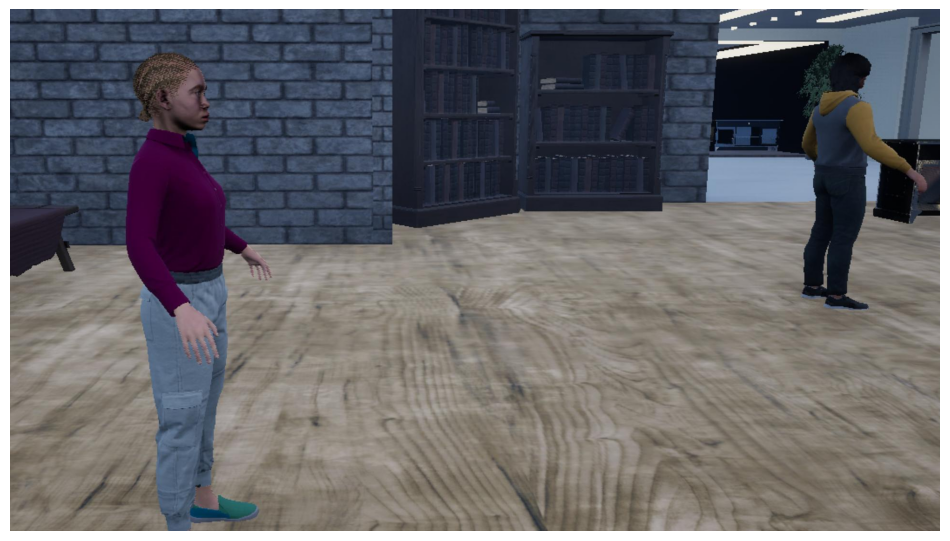

In [21]:
mg, annotation = train_dataset[0]

# Prepare image (same float scaled [0, 1] tensor format as Faster R-CNN)
np_img = np.array(img, dtype=np.float32) / 255.0
pixel_values = torch.from_numpy(np_img).permute(2, 0, 1).unsqueeze(0)
pixel_values = pixel_values.to(retinanet_adapter.device)

retinanet_adapter.model.eval()
with torch.no_grad():
    outputs = retinanet_adapter.model([pixel_values[0]])

raw_results = outputs[0]

results = {
    "boxes": raw_results["boxes"],
    "scores": raw_results["scores"],
    "labels": raw_results["labels"] 
}

plot_predictions(img, results, train_dataset, threshold=0.5)

## Train DETR
DETR is currently not supported by the torchvision framework. However, a derivate is available in the hugging face libraries. As Hugging face is open-source and readily integratable, we will be using their libraries.<br>
DETR expects COCO annotations.

In [22]:
# idea: Move dataset conversions to its own functions so we can have a look into the outputs
class DETRAdapter(BaseModelAdapter):
    def __init__(self, model, processor):
        super().__init__(output_classes=output_classes, device=DEVICE)
        self.model = model.to(self.device)
        self.processor = processor

        print(f'Model: {self.model} \n Num classes: {self.output_classes} \n Device: {self.device}')
        

    def prepare_item(self, images, annotations):
        targets = self._get_annotations(images, annotations)
        encoded_items = []

        # prepare annotations
        for img, target in zip(images, targets):
            coco_boxes = [self.convert_voc2coco(box.tolist()) for box in target["boxes"]]
            labels = target["labels"].tolist()
            image_id = target["image_id"]

            formatted_annotations = {
                    "image_id": image_id,
                    "annotations": [
                        {
                            "image_id": image_id,
                            "category_id": label,
                            "bbox": box,
                            "iscrowd": 0,
                            "area": box[2] * box[3],                         }
                        for box, label in zip(coco_boxes, labels)
                    ],
                }
            
            # prepare images
            np_img = np.array(img)

            encoded = self.processor(
                images=np_img,
                annotations=formatted_annotations,
                return_tensors="pt",
            )

            encoded = {
                k: v.squeeze(0) if isinstance(v, torch.Tensor) else v[0]
                for k, v in encoded.items()
            }

            encoded_items.append(encoded)

        return encoded_items



    def forward_train(self, images, annotations):
        encoded_items = self.prepare_item(images, annotations)

        # Move pixel values to GPU
        pixel_values = torch.stack(
            [item["pixel_values"] for item in encoded_items]
        ).to(self.device)

        detr_labels = []
        for item in encoded_items:
            device_labels = {
                k: v.to(self.device) if isinstance(v, torch.Tensor) else v 
                for k, v in item["labels"].items()
            }
            # Indent this so EVERY item in the batch is added to the list
            detr_labels.append(device_labels)

        # Forward pass through the model
        outputs = self.model(
            pixel_values=pixel_values,
            labels=detr_labels,
        )

        return outputs.loss
    


In [26]:
cats = train_dataset.coco.loadCats(train_dataset.coco.getCatIds())

# COCO id -> category name
catid_to_name = {cat["id"]: cat["name"] for cat in cats}

# Training label -> category name
id2label = {
    train_dataset.catid2label[cat_id]: catid_to_name[cat_id]
    for cat_id in train_dataset.catid2label
}

# Category name -> training label
label2id = {name: idx for idx, name in id2label.items()}

CHECKPOINT = "PekingU/rtdetr_v2_r50vd"
IMAGE_SIZE = 640

dataset_classes = len(train_dataset.catid2label) 
output_classes = dataset_classes   

detr_model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

detr_processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},)


detr_adapter = DETRAdapter(detr_model, detr_processor)


Some weights of RTDetrV2ForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_v2_r50vd and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([8]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([8, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([8]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([8, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([8]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([8, 256]) in the model instantiated
- model.decod

Model: RTDetrV2ForObjectDetection(
  (model): RTDetrV2Model(
    (backbone): RTDetrV2ConvEncoder(
      (model): RTDetrResNetBackbone(
        (embedder): RTDetrResNetEmbeddings(
          (embedder): Sequential(
            (0): RTDetrResNetConvLayer(
              (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (1): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (2): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
          )
          (

In [27]:
# test if the inputs are I/O correct — wrap the single item as a batch of 1
img, ann = train_dataset[0]

encoded = detr_adapter.prepare_item([img], [ann])

print(encoded[0].keys())
print(encoded[0]["labels"])

dict_keys(['pixel_values', 'labels'])
{'size': tensor([640, 640]), 'image_id': tensor([0]), 'class_labels': tensor([7, 1]), 'boxes': tensor([[0.2073, 0.5386, 0.1630, 0.9228],
        [0.9185, 0.3281, 0.1372, 0.4982]]), 'area': tensor([61599.0508, 27992.0137]), 'iscrowd': tensor([0, 0]), 'orig_size': tensor([1088, 1939])}


In [28]:
# reuse the resnet params
params = [p for p in detr_model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(      # train DETR with AdamW instead
    detr_model.parameters(),
    lr=5e-5,
    weight_decay=1e-4,
)

len_dataloader = len(train_loader)

detr_adapter = DETRAdapter(
    detr_model,
    detr_processor,
)


for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        
    # 1. Train
    train_loss = train_one_epoch(detr_adapter, train_loader, optimizer)
    
    # 2. Validate
    val_loss = validate_one_epoch(detr_adapter, val_loader)
    
    # 3. Telemetry Log
    print(f"Epoch {epoch+1} Complete | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Model: RTDetrV2ForObjectDetection(
  (model): RTDetrV2Model(
    (backbone): RTDetrV2ConvEncoder(
      (model): RTDetrResNetBackbone(
        (embedder): RTDetrResNetEmbeddings(
          (embedder): Sequential(
            (0): RTDetrResNetConvLayer(
              (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (1): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
            (2): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrV2FrozenBatchNorm2d()
              (activation): ReLU()
            )
          )
          (

Training: 100%|██████████| 101/101 [00:17<00:00,  5.66it/s, batch_loss=31.5026]


Epoch 1 Complete | Train Loss: 43.8315 | Val Loss: 28.7042

--- Epoch 2/15 ---


Training: 100%|██████████| 101/101 [00:17<00:00,  5.69it/s, batch_loss=22.0830]


Epoch 2 Complete | Train Loss: 25.1154 | Val Loss: 22.0451

--- Epoch 3/15 ---


...

Epoch 13 Complete | Train Loss: 8.5513 | Val Loss: 16.7581

--- Epoch 14/15 ---


Training: 100%|██████████| 101/101 [00:17<00:00,  5.64it/s, batch_loss=8.9035]


Epoch 14 Complete | Train Loss: 8.1936 | Val Loss: 17.2190

--- Epoch 15/15 ---


Training: 100%|██████████| 101/101 [00:17<00:00,  5.65it/s, batch_loss=11.0592]
                                                           

Epoch 15 Complete | Train Loss: 8.1422 | Val Loss: 15.9177


In [29]:
torch.save(detr_adapter.model.state_dict(), "models/detr_trained_weights.pth")
detr_processor.save_pretrained("./models/local_processor_config")  # Make this simply locally available

['./models/local_processor_config/preprocessor_config.json']

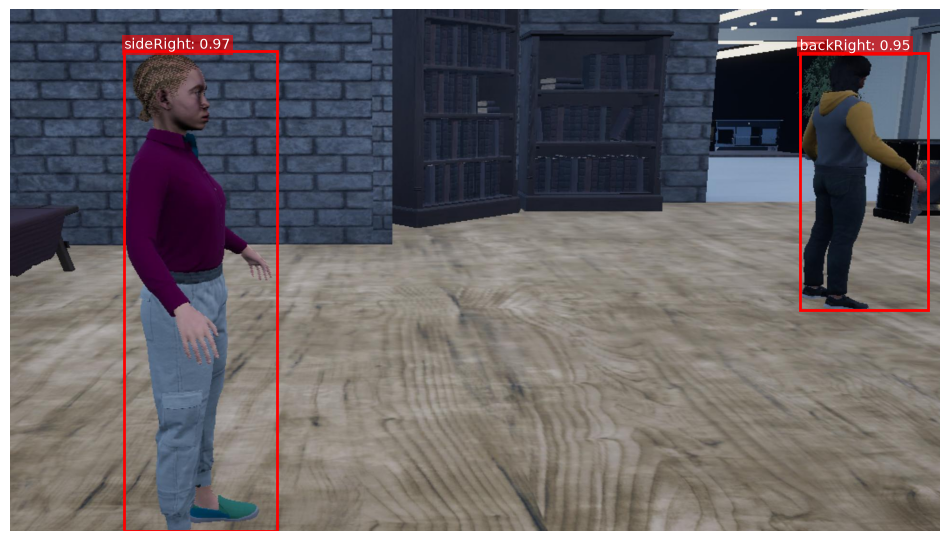

In [30]:
img, annotation = train_dataset[0]

inputs = detr_adapter.processor(images=img, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(detr_adapter.device)

with torch.no_grad():
    outputs = detr_adapter.model(pixel_values=pixel_values)

target_sizes = torch.tensor([img.size[::-1]]).to(detr_adapter.device)
results = detr_adapter.processor.post_process_object_detection(
    outputs, target_sizes=target_sizes, threshold=0.1 # Keep low here, let the function filter it
)[0]

plot_predictions(img, results, train_dataset, threshold=0.5)